# Proyek Klasifikasi Gambar: Animals-10

- **Nama:** [Ramdhan Wijaya]
- **Email:** [3337230033@untirta.ac.id]
- **ID Dicoding:** [raamwhy]

Notebook ini menggunakan dataset Animals-10 (26.179 gambar, 10 kelas)
Link: https://www.kaggle.com/datasets/viratkothari/animal10

## Import Semua Packages/Library yang Digunakan

In [375]:
import random
import shutil
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## Data Preparation

### Data Loading

In [310]:
def find_dataset_dir():
    candidates = [
        Path.cwd() / 'Animals-10',
        Path.cwd().parent / 'Animals-10',
        Path('/content/Animals-10'),
        Path('/content/drive/MyDrive/Animals-10'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Folder Animals-10 tidak ditemukan. Sesuaikan path dataset Anda.')

DATASET_DIR = find_dataset_dir()
print('Dataset directory:', DATASET_DIR)

class_names = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
class_to_index = {name: idx for idx, name in enumerate(class_names)}

image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
all_image_paths = sorted([
    p for p in DATASET_DIR.rglob('*')
    if p.suffix.lower() in image_extensions
])
all_labels = np.array([class_to_index[p.parent.name] for p in all_image_paths], dtype=np.int32)

print('Jumlah kelas:', len(class_names))
print('Nama kelas:', class_names)
print('Total gambar:', len(all_image_paths))

class_counts = Counter([p.parent.name for p in all_image_paths])
for class_name in class_names:
    print(f'- {class_name}: {class_counts[class_name]}')

Dataset directory: c:\Users\Ram Wijaya\klasifikasi-gambar\Animals-10
Jumlah kelas: 10
Nama kelas: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Total gambar: 26179
- butterfly: 2112
- cat: 1668
- chicken: 3098
- cow: 1866
- dog: 4863
- elephant: 1446
- horse: 2623
- sheep: 1820
- spider: 4821
- squirrel: 1862


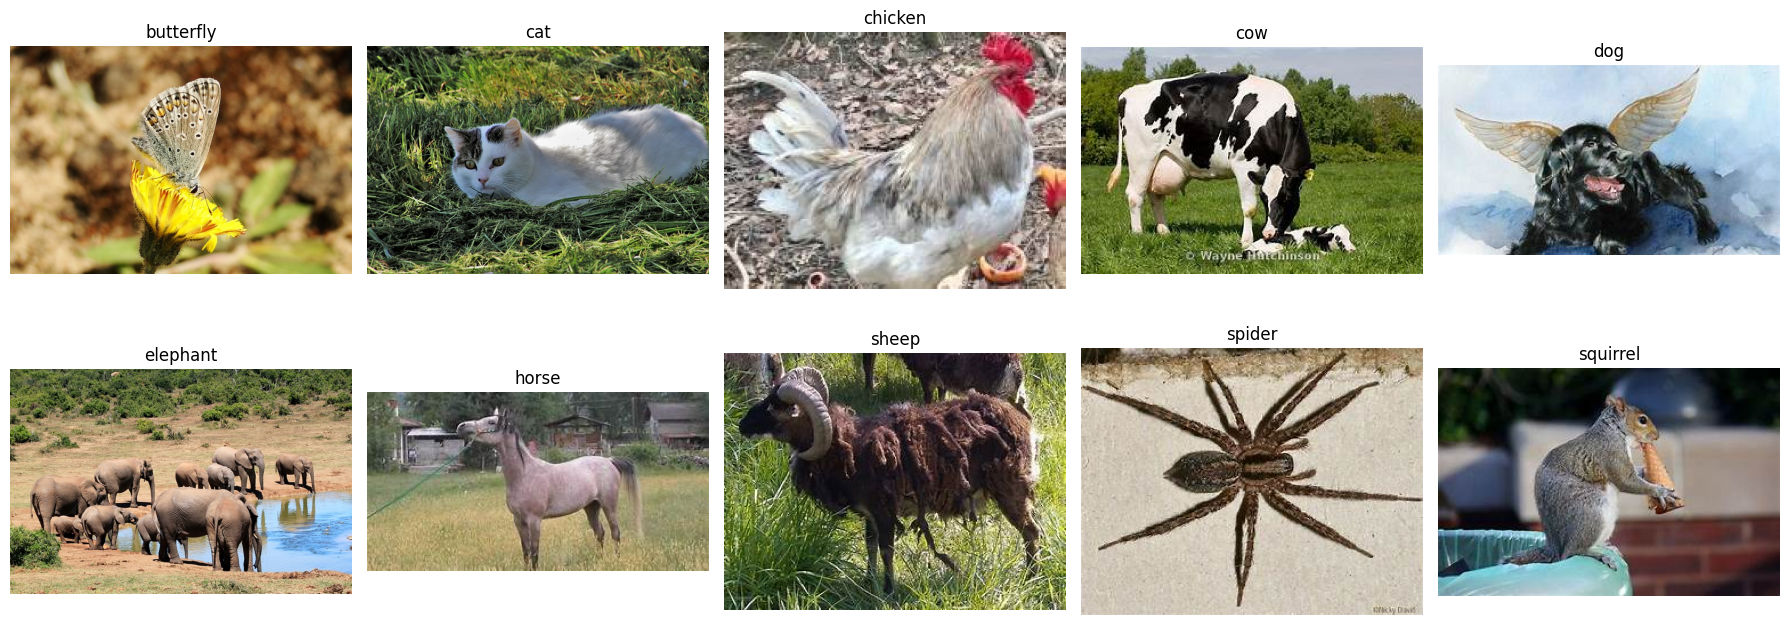

In [311]:
# Visualisasi sampel gambar tiap kelas
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    class_files = [p for p in all_image_paths if p.parent.name == class_name]
    sample_path = random.choice(class_files)
    with Image.open(sample_path) as img:
        axes[i].imshow(img.convert('RGB'))
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Data Preprocessing

#### Split Dataset

In [12]:
# Cek variasi resolusi gambar asli (tanpa preprocessing).
resolution_counter = Counter()
for img_path in all_image_paths:
    with Image.open(img_path) as img:
        resolution_counter[img.size] += 1

print('Jumlah resolusi unik:', len(resolution_counter))
print('10 resolusi terbanyak:')
for size, cnt in resolution_counter.most_common(10):
    print(f'- {size}: {cnt}')

Jumlah resolusi unik: 1002
10 resolusi terbanyak:
- (300, 225): 4397
- (300, 200): 3281
- (300, 300): 1192
- (300, 169): 1048
- (640, 426): 694
- (300, 199): 586
- (225, 300): 490
- (300, 240): 403
- (300, 188): 393
- (200, 300): 362


In [13]:
paths_np = np.array([str(p) for p in all_image_paths])
labels_np = all_labels.copy()

x_train, x_temp, y_train, y_temp = train_test_split(
    paths_np,
    labels_np,
    test_size=0.30,
    random_state=SEED,
    stratify=labels_np
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f'Train: {len(x_train)} ({len(x_train)/len(paths_np):.2%})')
print(f'Val:   {len(x_val)} ({len(x_val)/len(paths_np):.2%})')
print(f'Test:  {len(x_test)} ({len(x_test)/len(paths_np):.2%})')

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print('Class weights:', class_weight_dict)

Train: 18325 (70.00%)
Val:   3927 (15.00%)
Test:  3927 (15.00%)
Class weights: {0: 1.239851150202977, 1: 1.5689212328767124, 2: 0.8448593822037805, 3: 1.4031393568147015, 4: 0.538337250293772, 5: 1.8107707509881423, 6: 0.9980936819172114, 7: 1.4383830455259026, 8: 0.542962962962963, 9: 1.406369915579432}


In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name='data_augmentation')

def decode_resize(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

def build_dataset(image_paths, labels, training=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(image_paths), seed=SEED)
    ds = ds.map(decode_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(x_train, y_train, training=True, augment=True)
val_ds = build_dataset(x_val, y_val, training=False, augment=False)
test_ds = build_dataset(x_test, y_test, training=False, augment=False)
train_eval_ds = build_dataset(x_train, y_train, training=False, augment=False)

num_classes = len(class_names)
print('Dataset pipeline siap. Jumlah kelas:', num_classes)

Dataset pipeline siap. Jumlah kelas: 10


## Modelling

In [15]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
 )
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=IMG_SIZE + (3,)),
    tf.keras.layers.Rescaling(scale=1.0 / 127.5, offset=-1),
    base_model,
    tf.keras.layers.Conv2D(256, (1, 1), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
] , name='animals10_transfer_cnn')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

checkpoint_dir = Path('checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / 'best_model.keras'

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

INITIAL_EPOCHS = 12
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_stage1,
    class_weight=class_weight_dict
)

base_model.trainable = True
fine_tune_at = max(len(base_model.layers) - 40, 0)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

FINE_TUNE_EPOCHS = 20
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history_stage1.epoch[-1] + 1,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    callbacks=callbacks_stage2,
    class_weight=class_weight_dict
)

history_dict = {}
for key in ['accuracy', 'val_accuracy', 'loss', 'val_loss']:
    history_dict[key] = history_stage1.history.get(key, []) + history_stage2.history.get(key, [])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "animals10_transfer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,655,306 (10.13 MB)

 Trainable params: 396,810 (1.51 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Epoch 1/12
573/573 ━━━━━━━━━━━━━━━━━━━━ 200s 342ms/step - accuracy: 0.9010 - loss: 0.3308 - val_accuracy: 0.9595 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 2/12
573/573 ━━━━━━━━━━━━━━━━━━━━ 193s 335ms/step - accuracy: 0.9362 - loss: 0.2061 - val_accuracy: 0.9577 - val_loss: 0.1467 - learning_rate: 0.0010
Epoch 3/12
573/573 ━━━━━━━━━━━━━━━━━━━━ 194s 337ms/step - accuracy: 0.9443 - loss: 0.1742 - val_accuracy: 0.9623 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 4/12
573/573 ━━━━━━━━━━━━━━━━━━━━ 190s 330ms/step - accuracy: 0.9497 - loss: 0.1598 - val_accuracy: 0.9633 - val_loss: 0.1413 - learning_rate: 0.0010
Epoch 5/12
573/573 ━━━━━━━━━━━━━━━━━━━━ 190s 330ms/step - accuracy: 0.9529 - loss: 0.1550 - val_accuracy: 0.9559 - val_loss: 0.1524 - learning_rate: 0.0010
Epoch 6/12
573/573 ━━━━━━━━━━━━━━━━━━━━ 191s 333ms/step - accuracy: 0.9601 - loss: 0.1204 - val_accuracy: 0.9656 - val_loss: 0.1365 - learning_rate: 3.0000e-04
Epoch 7/12
573/573 ━━━━━━━━━━━━━━━━━━━━ 192s 333ms/step - ac

## Evaluasi dan Visualisasi

Train Accuracy: 0.9848 | Train Loss: 0.0453
Val Accuracy:   0.9659 | Val Loss:   0.1374
Test Accuracy:  0.9628 | Test Loss:  0.1470
Best Val Accuracy during training: 0.9687
Status: Memenuhi kriteria akurasi minimum 85%.


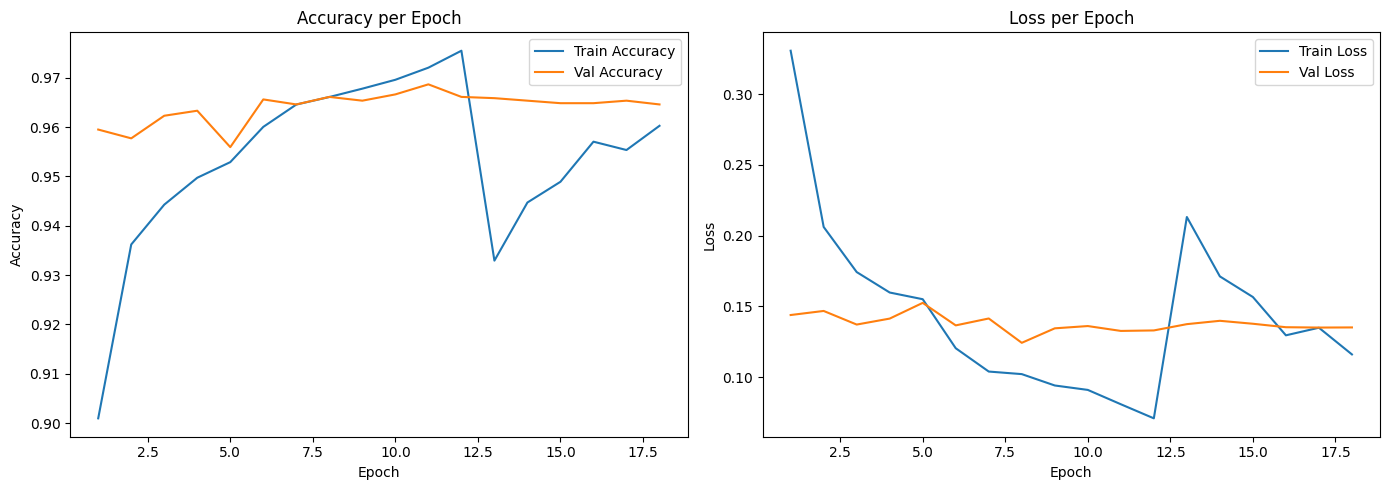

In [16]:
train_loss, train_acc = model.evaluate(train_eval_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f'Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}')
print(f'Val Accuracy:   {val_acc:.4f} | Val Loss:   {val_loss:.4f}')
print(f'Test Accuracy:  {test_acc:.4f} | Test Loss:  {test_loss:.4f}')

best_val_acc = max(history_dict['val_accuracy']) if history_dict['val_accuracy'] else 0.0
print(f'Best Val Accuracy during training: {best_val_acc:.4f}')

if train_acc >= 0.85 and test_acc >= 0.85:
    print('Status: Memenuhi kriteria akurasi minimum 85%.')
else:
    print('Status: Belum memenuhi kriteria 85%, lanjut tuning hyperparameter.')

epochs_range = range(1, len(history_dict['accuracy']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_dict['accuracy'], label='Train Accuracy')
plt.plot(epochs_range, history_dict['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_dict['loss'], label='Train Loss')
plt.plot(epochs_range, history_dict['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

ANALISIS DETAIL: PER-CLASS ACCURACY

Classification Report:

              precision    recall  f1-score   support

   butterfly       0.97      0.97      0.97       317
         cat       0.96      0.96      0.96       250
     chicken       0.97      0.98      0.98       465
         cow       0.85      0.96      0.90       280
         dog       0.98      0.96      0.97       729
    elephant       0.97      0.98      0.97       217
       horse       0.95      0.96      0.96       394
       sheep       0.96      0.88      0.92       273
      spider       0.99      0.97      0.98       723
    squirrel       0.96      0.97      0.97       279

    accuracy                           0.96      3927
   macro avg       0.96      0.96      0.96      3927
weighted avg       0.96      0.96      0.96      3927


Per-Class Accuracy:
- butterfly: 0.9748 (317 samples)
- cat: 0.9640 (250 samples)
- chicken: 0.9849 (465 samples)
- cow: 0.9607 (280 samples)
- dog: 0.9575 (729 samples)
- elephan

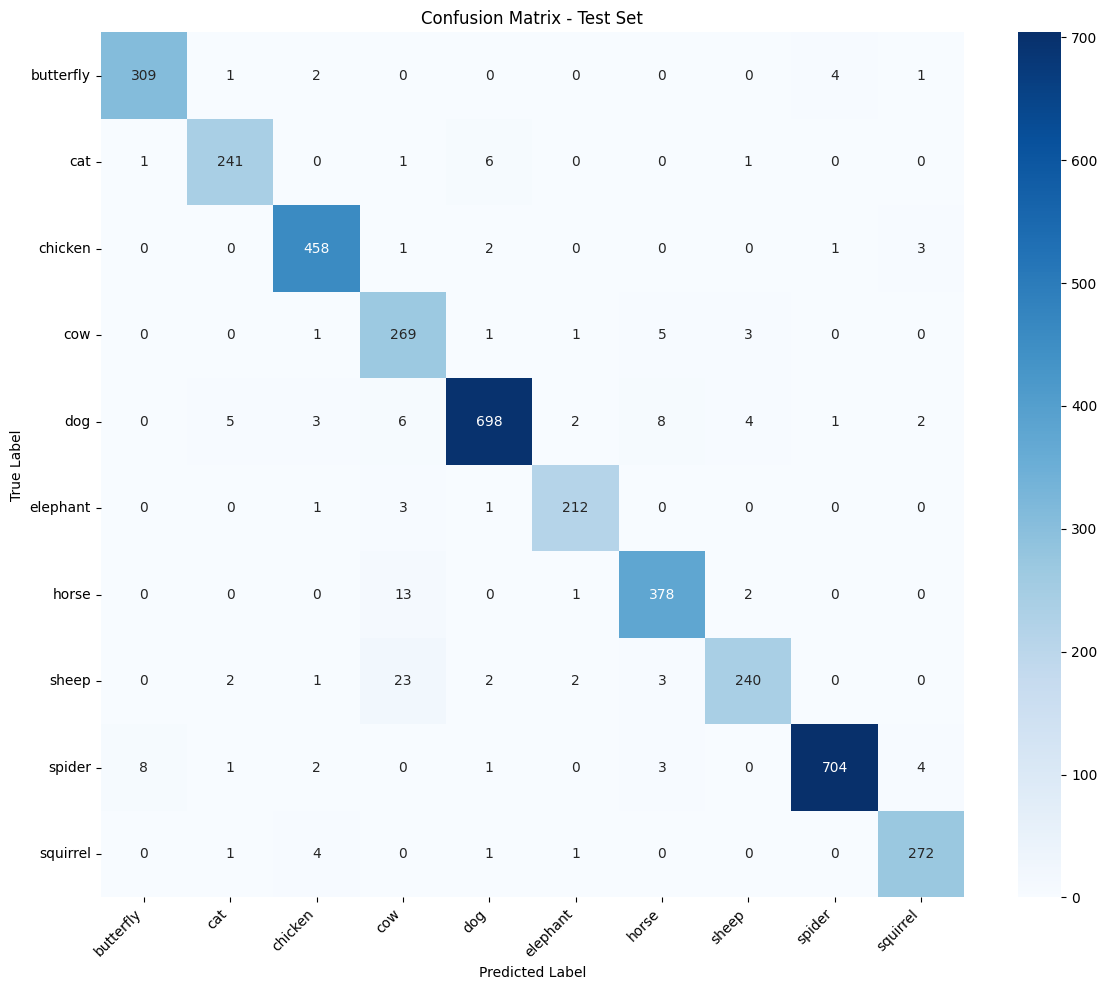

In [309]:
# Analisis Per-class accuracy dan confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("="*60)
print("ANALISIS DETAIL: PER-CLASS ACCURACY")
print("="*60)

# Prediksi pada test set
all_preds = []
all_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    all_preds.extend(pred_labels)
    all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Classification report per class
print("\nClassification Report:\n")
print(classification_report(all_true, all_preds, target_names=class_names))

# akurasi per class
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    mask = all_true == i
    if mask.sum() > 0:
        class_acc = (all_preds[mask] == i).sum() / mask.sum()
        print(f"- {class_name}: {class_acc:.4f} ({mask.sum()} samples)")

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Konversi Model

In [422]:
if (Path.cwd() / 'submission').exists():
    SUBMISSION_DIR = Path.cwd() / 'submission'
else:
    SUBMISSION_DIR = Path.cwd()

saved_model_dir = SUBMISSION_DIR / 'saved_model'
tflite_dir = SUBMISSION_DIR / 'tflite'
tfjs_dir = SUBMISSION_DIR / 'tfjs_model'

saved_model_dir.mkdir(parents=True, exist_ok=True)
tflite_dir.mkdir(parents=True, exist_ok=True)
tfjs_dir.mkdir(parents=True, exist_ok=True)

# 1) SavedModel
tf.saved_model.save(model, str(saved_model_dir))
print('SavedModel tersimpan di:', saved_model_dir)

INFO:tensorflow:Assets written to: c:\Users\Ram Wijaya\klasifikasi-gambar\submission\saved_model\assets


INFO:tensorflow:Assets written to: c:\Users\Ram Wijaya\klasifikasi-gambar\submission\saved_model\assets


SavedModel tersimpan di: c:\Users\Ram Wijaya\klasifikasi-gambar\submission\saved_model


In [423]:
# 2) TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []
tflite_model = converter.convert()

tflite_path = tflite_dir / 'model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

label_path = tflite_dir / 'label.txt'
with open(label_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(class_names))

print('TFLite model tersimpan di:', tflite_path)
print('Label tersimpan di:', label_path)

INFO:tensorflow:Assets written to: C:\Users\RAMWIJ~1\AppData\Local\Temp\tmp_eeaf7s7\assets


INFO:tensorflow:Assets written to: C:\Users\RAMWIJ~1\AppData\Local\Temp\tmp_eeaf7s7\assets


Saved artifact at 'C:\Users\RAMWIJ~1\AppData\Local\Temp\tmp_eeaf7s7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_177')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2367781404112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781401232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781403344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367747348176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781402960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781402576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781395280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781403536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2367781393744: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [ ]:
# 3) TFJS
if tfjs_dir.exists():
    shutil.rmtree(tfjs_dir)
tfjs_dir.mkdir(parents=True, exist_ok=True)

try:
    import numpy as np
    if not hasattr(np, 'object'):
        np.object = object
    if not hasattr(np, 'bool'):
        np.bool = bool
    if not hasattr(np, 'int'):
        np.int = int
    if not hasattr(np, 'float'):
        np.float = float

    from tensorflowjs.converters.converter import convert

    print(f'\nSource SavedModel: {saved_model_dir}')
    print(f'Target TFJS: {tfjs_dir}')

    convert([
        '--input_format=tf_saved_model',
        '--output_format=tfjs_graph_model',
        '--weight_shard_size_bytes=104857600',  # 100 MB
        str(saved_model_dir),
        str(tfjs_dir),
    ])

    print('\n✅ TFJS model berhasil disimpan!')

except Exception as e:
    print(f'❌ Error konversi TFJS: {e}')



Source SavedModel: c:\Users\Ram Wijaya\klasifikasi-gambar\submission\saved_model
Target TFJS: c:\Users\Ram Wijaya\klasifikasi-gambar\submission\tfjs_model
Writing weight file c:\Users\Ram Wijaya\klasifikasi-gambar\submission\tfjs_model\model.json...

✅ TFJS model berhasil disimpan!


## Inference (Optional)

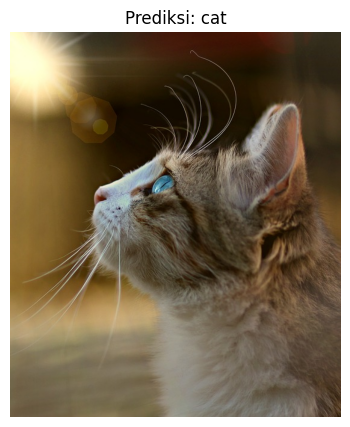

In [457]:
# Inference TFLite: ambil gambar random dari Animals-10 dan tampilkan hasil prediksi.

sample_path = Path(random.choice(all_image_paths))

if 'label_path' in globals() and label_path.exists():
    with open(label_path, 'r', encoding='utf-8') as f:
        tflite_class_names = [line.strip() for line in f if line.strip()]
else:
    tflite_class_names = class_names

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

with Image.open(sample_path).convert('RGB') as img:
    resized = img.resize(IMG_SIZE)
    input_array = np.array(resized, dtype=np.float32)

input_dtype = input_details[0]['dtype']
if np.issubdtype(input_dtype, np.floating):
    input_tensor = np.expand_dims(input_array, axis=0).astype(input_dtype)
else:
    scale, zero_point = input_details[0]['quantization']
    if scale and scale > 0:
        input_tensor = input_array / scale + zero_point
    else:
        input_tensor = input_array
    if np.issubdtype(input_dtype, np.integer):
        info = np.iinfo(input_dtype)
        input_tensor = np.clip(np.round(input_tensor), info.min, info.max)
    input_tensor = np.expand_dims(input_tensor.astype(input_dtype), axis=0)

interpreter.set_tensor(input_details[0]['index'], input_tensor)
interpreter.invoke()
pred = interpreter.get_tensor(output_details[0]['index'])[0]
pred_idx = int(np.argmax(pred))

plt.figure(figsize=(5, 5))
with Image.open(sample_path).convert('RGB') as img_show:
    plt.imshow(img_show)
plt.axis('off')
plt.title(f'Prediksi: {tflite_class_names[pred_idx]}')
plt.show()



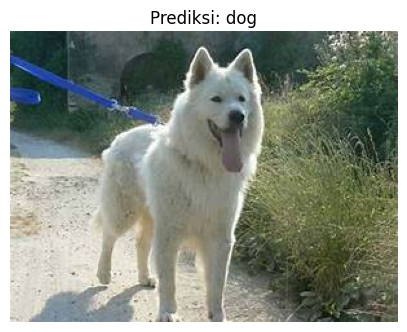

In [476]:
# Inference SavedModel: ambil gambar random dari Animals-10 dan tampilkan hasil prediksi.

sample_path = Path(random.choice(all_image_paths))

if 'label_path' in globals() and label_path.exists():
    with open(label_path, 'r', encoding='utf-8') as f:
        savedmodel_class_names = [line.strip() for line in f if line.strip()]
else:
    savedmodel_class_names = class_names

loaded_saved_model = tf.saved_model.load(str(saved_model_dir))
infer_fn = loaded_saved_model.signatures['serving_default']

with Image.open(sample_path).convert('RGB') as img:
    resized = img.resize(IMG_SIZE)
    input_array = np.array(resized, dtype=np.float32)

input_tensor = np.expand_dims(input_array, axis=0)
output_tensor = infer_fn(tf.constant(input_tensor))
pred = list(output_tensor.values())[0][0].numpy()
pred_idx = int(np.argmax(pred))

plt.figure(figsize=(5, 5))
with Image.open(sample_path).convert('RGB') as img_show:
    plt.imshow(img_show)
plt.axis('off')
plt.title(f'Prediksi: {savedmodel_class_names[pred_idx]}')
plt.show()
